# UNIVERSIDAD TECMILENIO

### Ingeniería en Software

## Actividad 3

Caso: Clasificación con SVM y agrupamiento con K-Means sobre el dataset Breast Cancer Wisconsin

Elaborado por:

**Gael Rodríguez Jiménez**

Matrícula: AL03109273

Modalidad: Analítica de datos

Fecha de entrega: 05 de septiembre del 2026

Notebook de la actividad (GitHub): https://github.com/Maade0n/analitica-datos-tecmilenio/blob/main/Actividad3/Actividad3_SVM_Clustering.ipynb

## 1. Introducción

En esta tarea utilicé el mismo conjunto de datos para realizar dos tipos de análisis. Primero, entrené una máquina de soporte vectorial (SVM) con el fin de predecir si un tumor es maligno o benigno. Luego, apliqué K-Means para verificar si los datos se agrupan de manera independiente, sin considerar el diagnóstico. Al final, comparé ambos resultados.

Utilicé el conjunto de datos Breast Cancer Wisconsin, que está disponible en scikit-learn. Cada entrada representa una imagen de una biopsia de una masa en el seno. Se midieron 10 características de los núcleos celulares de cada imagen (como el radio, la textura, el área, la concavidad, etc.), y de cada característica se registró la media, el error estándar y el valor máximo, lo que genera 30 variables numéricas. La variable que se quiere predecir es el diagnóstico.

**Tabla 1**

*Datos generales del dataset*

| Campo | Detalle |
|---|---|
| Nombre | Breast Cancer Wisconsin (Diagnostic) |
| Fuente | UCI Machine Learning Repository, cargado con load_breast_cancer de scikit-learn |
| Registros | 569 (357 benignos y 212 malignos) |
| Variables | 30 predictoras numéricas y 1 variable objetivo |
| Faltantes y duplicados | Ninguno |

Nota. Consultado el 5 de septiembre de 2026 en https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

Las preguntas que guiaron el trabajo fueron:

- **Supervisada:** ¿se puede predecir si un tumor es maligno o benigno a partir de sus 30 medidas?
- **No supervisada:** sin usar el diagnóstico, ¿los datos se separan en grupos naturales? ¿Cuántos y qué los diferencia?

## 2. Preparación de los datos

El conjunto de datos no contenía datos faltantes ni repetidos, por lo que no fue necesario quitar registros. Solo modifiqué la codificación del diagnóstico para que 1 representara el caso maligno, que es la clase que nos interesa detectar. Separé las etiquetas para utilizarlas únicamente en la evaluación de la SVM y en la comparación final.

In [1]:
# Importamos las librerias que vamos a usar
import pandas as pd                      # pandas: para manejar tablas de datos
import numpy as np                       # numpy: para operaciones con numeros
import matplotlib.pyplot as plt          # matplotlib: para hacer graficas
import seaborn as sns                    # seaborn: graficas mas bonitas (mapas de calor)

from sklearn.datasets import load_breast_cancer        # funcion que trae el dataset
from sklearn.preprocessing import StandardScaler       # herramienta para escalar
from sklearn.pipeline import Pipeline                  # une escalado + modelo en un solo paso
from sklearn.model_selection import train_test_split   # divide en entrenamiento y prueba
from sklearn.svm import SVC                            # el modelo SVM
from sklearn.cluster import KMeans                     # el algoritmo K-Means
from sklearn.decomposition import PCA                  # reduce las 30 variables a 2 para graficar
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, silhouette_score)

SEMILLA = 42   # numero fijo para que los resultados salgan siempre iguales

# Cargamos el dataset como tabla (DataFrame)
datos = load_breast_cancer(as_frame=True)
df = datos.frame

# Revision inicial de la estructura
print('Registros:', df.shape[0])                          # numero de filas
print('Columnas :', df.shape[1])                          # 30 variables + la columna target
print('Tipos de datos:', df.dtypes.value_counts().to_dict())   # cuantas columnas hay de cada tipo
print('Valores faltantes:', df.isna().sum().sum())        # suma de todos los vacios
print('Registros duplicados:', df.duplicated().sum())     # filas repetidas

# En scikit-learn 0 = maligno y 1 = benigno. Lo cambiamos para que 1 = maligno
y = (df['target'] == 0).astype(int)

# X son las 30 variables predictoras (todas las columnas menos target)
X = df[datos.feature_names]

# Distribucion de la variable objetivo
print('\nDistribucion del diagnostico:')
print(y.value_counts().rename({0: 'Benigno (0)', 1: 'Maligno (1)'}))

Registros: 569
Columnas : 31
Tipos de datos: {dtype('float64'): 30, dtype('int64'): 1}
Valores faltantes: 0
Registros duplicados: 0

Distribucion del diagnostico:
target
Benigno (0)    357
Maligno (1)    212
Name: count, dtype: int64


Las variables presentan escalas bastante diferentes: el área alcanza valores de miles, mientras que otras están cerca de 0.05. Esto influye en ambos modelos, ya que trabajan con distancias entre puntos, y las variables con grandes valores acabarían dominando el cálculo. Por ello, utilicé StandardScaler. En la SVM, lo incluí en un Pipeline para que el escalado se realice solo con los datos de entrenamiento.

In [2]:
# Mostramos que las variables tienen escalas muy distintas
escalas = X.describe().T[['min', 'max']]          # minimo y maximo de cada variable
print(escalas.loc[['mean area', 'mean smoothness', 'mean fractal dimension']])

# Escalamos las 30 variables (media 0 y desviacion 1).
# Este escalado se usa para K-Means. Para la SVM el escalado va dentro del Pipeline.
X_esc = StandardScaler().fit_transform(X)

                              min         max
mean area               143.50000  2501.00000
mean smoothness           0.05263     0.16340
mean fractal dimension    0.04996     0.09744


Para la SVM, particioné los datos en un 80 % para entrenamiento (455 registros) y un 20 % para prueba (114), con una semilla de 42 y estratificando para preservar la proporción de casos malignos. Así, el modelo se evalúa con datos que no ha encontrado durante el proceso de entrenamiento.

In [3]:
# Dividimos: 80 % entrenamiento y 20 % prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 20 % para prueba
    stratify=y,              # mantiene la misma proporcion de malignos en ambos
    random_state=SEMILLA)    # semilla fija

print('Entrenamiento:', len(X_train), 'registros')
print('Prueba       :', len(X_test), 'registros')
print('% malignos en entrenamiento:', round(y_train.mean() * 100, 2))
print('% malignos en prueba       :', round(y_test.mean() * 100, 2))

Entrenamiento: 455 registros
Prueba       : 114 registros
% malignos en entrenamiento: 37.36
% malignos en prueba       : 36.84


## 3. Análisis supervisado con SVM

### 3.1 Comparación de los dos modelos

Entrené dos modelos con los mismos datos: uno con kernel lineal y otro con kernel RBF. Como el problema tiene dos clases, las métricas se calcularon para la clase maligna.

**Tabla 2**

*Resultados de los modelos SVM en el conjunto de prueba*

In [4]:
# Funcion que calcula las 4 metricas para la clase maligna (1)
def metricas(nombre, kernel, y_real, y_pred):
    return {'Modelo SVM': nombre, 'Kernel': kernel,
            'Accuracy' : f'{accuracy_score(y_real, y_pred):.4f}',     # aciertos totales
            'Precision': f'{precision_score(y_real, y_pred):.4f}',    # de los que dijo maligno, cuantos si eran
            'Recall'   : f'{recall_score(y_real, y_pred):.4f}',       # de los malignos reales, cuantos detecto
            'F1-score' : f'{f1_score(y_real, y_pred):.4f}'}           # promedio entre precision y recall
# (f'{valor:.4f}' escribe el numero siempre con 4 decimales)

# Modelo 1: escalado + SVM con kernel lineal
modelo_1 = Pipeline([('escalado', StandardScaler()),
                     ('svm', SVC(kernel='linear', random_state=SEMILLA))])
# Modelo 2: escalado + SVM con kernel RBF
modelo_2 = Pipeline([('escalado', StandardScaler()),
                     ('svm', SVC(kernel='rbf', random_state=SEMILLA))])

modelo_1.fit(X_train, y_train)    # entrena con los datos de entrenamiento
modelo_2.fit(X_train, y_train)

# Predice sobre prueba y arma la tabla
tabla_2 = pd.DataFrame([
    metricas('Modelo 1', 'Lineal', y_test, modelo_1.predict(X_test)),
    metricas('Modelo 2', 'RBF',    y_test, modelo_2.predict(X_test)),
])
tabla_2.style.hide(axis='index')   # muestra la tabla sin la columna de numeros de fila

Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
Modelo 1,Lineal,0.9649,1.0000,0.9048,0.9500
Modelo 2,RBF,0.9737,1.0000,0.9286,0.9630


Nota. Resultados sobre 114 registros de prueba.

El modelo con kernel RBF fue un poco mejor. Los dos tuvieron precisión perfecta, o sea que nunca marcaron como maligno un caso benigno. La diferencia estuvo en el recall: el lineal dejó pasar 4 tumores malignos y el RBF solo 3.

### 3.2 Ajuste de hiperparámetros

Luego cambié C y gamma en el modelo RBF. C determina la severidad del castigo a los errores: con un valor bajo de C, el margen es amplio y la línea divisoria es sencilla, aunque el modelo puede ser insuficiente; en cambio, con un C elevado, el margen se estrecha y el modelo se ajusta en exceso a los datos con los que se entrena. Gamma regula la extensión de la influencia de cada punto: si gamma es demasiado alto, la línea divisoria se vuelve muy complicada y el modelo se dedica a memorizar en lugar de realmente aprender.

**Tabla 3**

*Efecto del valor de C (kernel RBF, gamma = 0.01)*

In [5]:
# Probamos distintos valores de C dejando gamma fijo en 0.01
resultado = {0.01: 'Subajuste', 1: 'Aceptable', 10: 'Mejor resultado', 1000: 'Sobreajuste'}
filas = []
for C in [0.01, 1, 10, 1000]:
    m = Pipeline([('escalado', StandardScaler()),
                  ('svm', SVC(kernel='rbf', C=C, gamma=0.01, random_state=SEMILLA))])
    m.fit(X_train, y_train)
    filas.append({'C': str(C),
                  'F1 entrenamiento': f'{f1_score(y_train, m.predict(X_train)):.4f}',  # F1 con datos vistos
                  'F1 prueba'       : f'{f1_score(y_test, m.predict(X_test)):.4f}',    # F1 con datos nuevos
                  'Resultado'       : resultado[C]})
tabla_3 = pd.DataFrame(filas)

# Caso extra de la nota: gamma = 1 con C = 10
m = Pipeline([('escalado', StandardScaler()),
              ('svm', SVC(kernel='rbf', C=10, gamma=1, random_state=SEMILLA))])
m.fit(X_train, y_train)
print('gamma = 1 -> F1 entrenamiento:', f'{f1_score(y_train, m.predict(X_train)):.4f}',
      '| F1 prueba:', f'{f1_score(y_test, m.predict(X_test), zero_division=0):.4f}')
tabla_3.style.hide(axis='index')

gamma = 1 -> F1 entrenamiento: 1.0000 | F1 prueba: 0.0000


C,F1 entrenamiento,F1 prueba,Resultado
0.01,0.0000,0.0000,Subajuste
1,0.9668,0.9367,Aceptable
10,0.9820,0.9756,Mejor resultado
1000,1.0000,0.9412,Sobreajuste


Nota. Con gamma = 1 pasó algo parecido pero más extremo: F1 de 1.0000 en entrenamiento y 0.0000 en prueba.

Con C = 1000 el modelo acertó todo en entrenamiento pero bajó en prueba, lo que es una señal clara de sobreajuste. La mejor combinación fue C = 10 y gamma = 0.01.

### 3.3 Matriz de confusión del mejor modelo

**Figura 1**

*Matriz de confusión del modelo SVM con C = 10 y gamma = 0.01*

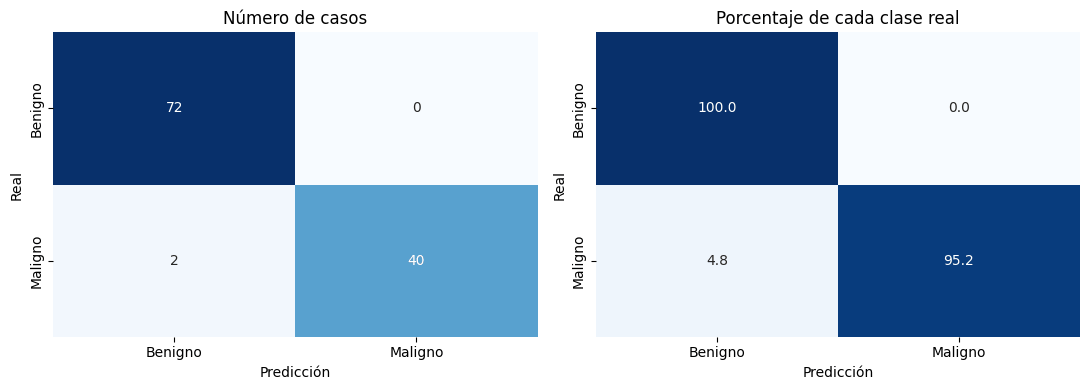

Accuracy: 98.25 %
Malignos detectados: 40 de 42


In [6]:
# Mejor modelo: kernel RBF con C = 10 y gamma = 0.01
mejor = Pipeline([('escalado', StandardScaler()),
                  ('svm', SVC(kernel='rbf', C=10, gamma=0.01, random_state=SEMILLA))])
mejor.fit(X_train, y_train)
pred = mejor.predict(X_test)

mc = confusion_matrix(y_test, pred)                    # tabla de aciertos y errores
mc_pct = mc / mc.sum(axis=1, keepdims=True) * 100      # lo mismo en porcentaje por fila

etiquetas = ['Benigno', 'Maligno']
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(mc, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=etiquetas, yticklabels=etiquetas)
ax[0].set_title('Número de casos'); ax[0].set_xlabel('Predicción'); ax[0].set_ylabel('Real')
sns.heatmap(mc_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False, ax=ax[1],
            xticklabels=etiquetas, yticklabels=etiquetas)
ax[1].set_title('Porcentaje de cada clase real'); ax[1].set_xlabel('Predicción'); ax[1].set_ylabel('Real')
plt.tight_layout(); plt.show()

print('Accuracy:', round(accuracy_score(y_test, pred) * 100, 2), '%')
print('Malignos detectados:', mc[1, 1], 'de', mc[1].sum())

Nota. Izquierda: número de casos. Derecha: porcentaje de cada clase real.

Este modelo alcanzó una precisión del 98.25 % y identificó 40 de los 42 cánceres. Clasificó correctamente los 72 casos benignos y solo tuvo dos fallos, ambos falsos negativos: cánceres que identificó como benignos. La categoría benigna fue la más sencilla de diferenciar.

Esto ilustra por qué no es suficiente fijarse solo en la precisión. Un modelo que solo indicara "benigno" tendría un 63 % de precisión sin detectar ningún caso de cáncer. En esta situación, lo más crítico es el recall, ya que un falso negativo supone un riesgo mucho mayor que un falso positivo.

## 4. Análisis no supervisado con K-Means

### 4.1 Elección del número de grupos

Para esta parte quité la variable objetivo y apliqué K-Means sobre las mismas 30 variables escaladas. Probé valores de k entre 2 y 6 con el método del codo y el silhouette score.

**Figura 2**

*Método del codo y silhouette score*

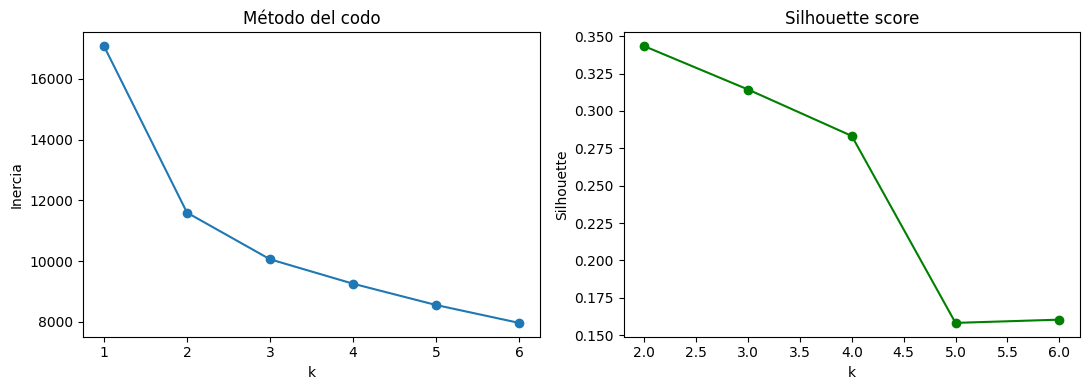

k = 2 -> silhouette = 0.3434
k = 3 -> silhouette = 0.3144
k = 4 -> silhouette = 0.2833
k = 5 -> silhouette = 0.1582
k = 6 -> silhouette = 0.1604


In [7]:
# Probamos K-Means con k de 2 a 6 (sin usar el diagnostico, solo X_esc)
ks = range(2, 7)
inercias, siluetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_esc)
    inercias.append(km.inertia_)                              # distancia interna de los grupos
    siluetas.append(silhouette_score(X_esc, km.labels_))      # que tan separados estan

# k = 1 solo se agrega como punto de partida de la curva del codo
inercia_k1 = KMeans(n_clusters=1, n_init=10, random_state=SEMILLA).fit(X_esc).inertia_

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([1] + list(ks), [inercia_k1] + inercias, 'o-')
ax[0].set_title('Método del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(list(ks), siluetas, 'o-', color='green')
ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

for k, s in zip(ks, siluetas):
    print('k =', k, '-> silhouette =', round(s, 4))

Nota. El silhouette score más alto fue 0.3434 con k = 2.

Elegí k = 2 porque ahí el silhouette score fue el más alto y la gráfica del codo muestra el cambio más fuerte. El valor de 0.34 indica que sí hay dos grupos, pero no están totalmente separados.

### 4.2 Descripción de los grupos

**Tabla 4**

*Tamaño y promedios de los grupos*

In [8]:
# K-Means final con k = 2
kmeans = KMeans(n_clusters=2, n_init=10, random_state=SEMILLA)
grupos = kmeans.fit_predict(X_esc)       # a que grupo quedo cada registro (0 o 1)

from decimal import Decimal, ROUND_HALF_UP

def redondear(valor, decimales):
    # Redondeo escolar: 17.415 -> 17.42 (primero a 3 decimales para quitar ruido del float)
    return str(Decimal(str(round(valor, 3))).quantize(Decimal(1).scaleb(-decimales), rounding=ROUND_HALF_UP))

# Promedio de las variables principales en cada grupo
prom = X.assign(Grupo=grupos).groupby('Grupo')[
    ['mean radius', 'mean area', 'mean concavity', 'mean concave points']].mean()

tabla_4 = pd.DataFrame({
    'Variable': ['Registros', 'mean radius', 'mean area', 'mean concavity', 'mean concave points'],
    'Grupo 0' : [str((grupos == 0).sum()), redondear(prom.loc[0, 'mean radius'], 2), redondear(prom.loc[0, 'mean area'], 2),
                 redondear(prom.loc[0, 'mean concavity'], 3), redondear(prom.loc[0, 'mean concave points'], 3)],
    'Grupo 1' : [str((grupos == 1).sum()), redondear(prom.loc[1, 'mean radius'], 2), redondear(prom.loc[1, 'mean area'], 2),
                 redondear(prom.loc[1, 'mean concavity'], 3), redondear(prom.loc[1, 'mean concave points'], 3)],
})
tabla_4.style.hide(axis='index')

Variable,Grupo 0,Grupo 1
Registros,375,194
mean radius,12.43,17.42
mean area,486.77,979.86
mean concavity,0.043,0.178
mean concave points,0.026,0.093


Nota. Valores promedio en las unidades originales.

El grupo 0 presenta núcleos de menor tamaño y con contornos más suaves. En cambio, el grupo 1 se caracteriza por tener núcleos de mayor tamaño y con contornos mucho más ásperos. La diferencia más notable entre ambos grupos es la concavidad, que en el grupo 1 es cuatro veces más superior. Una primera interpretación sugiere que el grupo 1 podría relacionarse con tejido que tiene alteraciones, aunque K-Means no puede determinarlo.

**Figura 3**

*Grupos de K-Means y diagnóstico real proyectados con PCA*

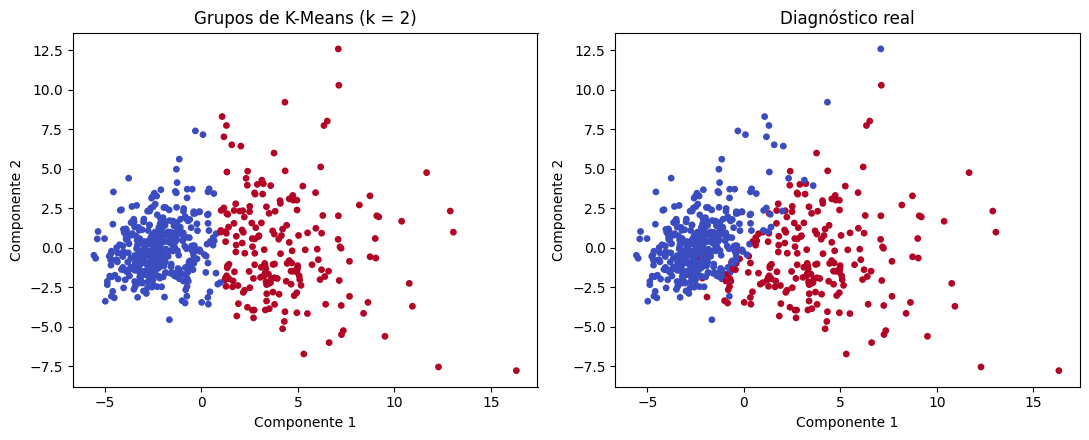

In [9]:
# PCA reduce las 30 variables a 2 componentes para poder graficar
coords = PCA(n_components=2, random_state=SEMILLA).fit_transform(X_esc)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
# Izquierda: colores segun el grupo de K-Means
ax[0].scatter(coords[:, 0], coords[:, 1], c=grupos, cmap='coolwarm', s=15)
ax[0].set_title('Grupos de K-Means (k = 2)')
# Derecha: colores segun el diagnostico real (solo para comparar)
ax[1].scatter(coords[:, 0], coords[:, 1], c=y, cmap='coolwarm', s=15)
ax[1].set_title('Diagnóstico real')
for a in ax:
    a.set_xlabel('Componente 1'); a.set_ylabel('Componente 2')
plt.tight_layout(); plt.show()

Nota. A la izquierda, colores según K-Means; a la derecha, según el diagnóstico real. El diagnóstico solo se usó para colorear.

## 5. Comparación de clusters y clases reales

**Tabla 5**

*Grupos de K-Means frente al diagnóstico real*

In [10]:
# Cruzamos los grupos de K-Means con el diagnostico real
tabla_5 = pd.crosstab(pd.Series(grupos, name='Grupo'),
                      y.map({0: 'Benigno', 1: 'Maligno'}).rename('Diagnóstico'))
tabla_5['Total'] = tabla_5.sum(axis=1)
tabla_5.index = ['Grupo 0', 'Grupo 1']

# Coincidencia: grupo 0 = benigno y grupo 1 = maligno
coincidencia = (tabla_5.loc['Grupo 0', 'Benigno'] + tabla_5.loc['Grupo 1', 'Maligno']) / len(y) * 100
mezclados = tabla_5.loc['Grupo 0', 'Maligno'] + tabla_5.loc['Grupo 1', 'Benigno']
print('Coincidencia:', round(coincidencia, 1), '%')
print('Casos mezclados:', mezclados)
tabla_5

Coincidencia: 90.5 %
Casos mezclados: 54


Diagnóstico,Benigno,Maligno,Total
Grupo 0,339,36,375
Grupo 1,18,176,194


Hay una coincidencia parcial bastante elevada: el grupo 0 es casi completamente benigno, mientras que el grupo 1 es casi totalmente maligno, alcanzando un 90.5 % de concordancia. Sin embargo, 54 casos se encontraron confundidos, especialmente en el área donde se unen ambos grupos.

No se debe suponer que los clústeres coincidan con las etiquetas. K-Means agrupa basándose en similitudes geométricas, no en diagnósticos, y asume que los grupos son redondeados y de tamaño similar. Además, un tumor maligno en sus etapas iniciales puede presentar células muy semejantes a las de un tumor benigno. Por eso, esos casos terminan en el grupo "incorrecto", aunque el algoritmo esté funcionando correctamente.

## 6. Conclusión

La SVM proporcionó resultados más fáciles de entender, ya que se contrasta directamente con el diagnóstico real y cada métrica es clara en su significado. Ofreció un modelo capaz de clasificar nuevos casos con un 98 % de precisión y un alto nivel de recuperación. Por otro lado, K-Means requirió más análisis de mi parte, pero ayudó a identificar que los datos se organizan en dos grupos naturales que se distinguen principalmente por la forma irregular de los bordes de las células.

Entre las limitaciones se encuentran que la SVM depende de la existencia de datos etiquetados, que el conjunto de prueba es reducido y que K-Means asume que los grupos son redondos, viéndose influenciado por variables que están muy correlacionadas, como el radio, el perímetro y el área.

La principal diferencia es que el aprendizaje supervisado se utiliza para predecir clases que ya conocemos, como en diagnósticos o en la detección de fraude. En cambio, el no supervisado se usa para analizar datos sin etiquetas y detectar patrones, como en la segmentación de clientes. En este caso, ambos métodos se complementan: K-Means reveló que ya había separaciones en los datos y la SVM utilizó esa información para hacer predicciones.

## 7. Referencias

Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

scikit-learn developers. (s.f.). load_breast_cancer. Recuperado el 5 de septiembre de 2026 de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

Wolberg, W. H., Street, W. N. y Mangasarian, O. L. (1995). Breast Cancer Wisconsin (Diagnostic) [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B